# Bivariate & Multivariate analysis


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot

In [30]:
titanic = pd.read_csv("titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
tips = sns.load_dataset('tips')     # build-in data-set present on seaborn
tips.sample(5).reset_index()

,index,total_bill,tip,sex,smoker,day,time,size
0,88,24.71,5.85,Male,No,Thur,Lunch,2
1,49,18.04,3.00,Male,No,Sun,Dinner,2
2,111,7.25,1.00,Female,No,Sat,Dinner,1
3,120,11.69,2.31,Male,No,Thur,Lunch,2
4,114,25.71,4.00,Female,No,Sun,Dinner,3


In [32]:
flights = sns.load_dataset('flights')          # build-in data-set present on seaborn
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [33]:
iris = sns.load_dataset('iris')                # build-in data-set present on seaborn
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<h1 style="color:blue">1).  Scatterplot (Numerical-Numerical)</h1>

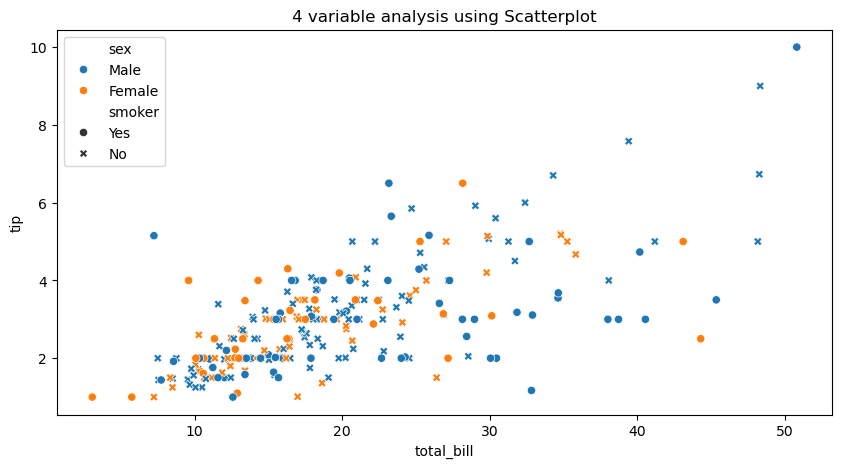

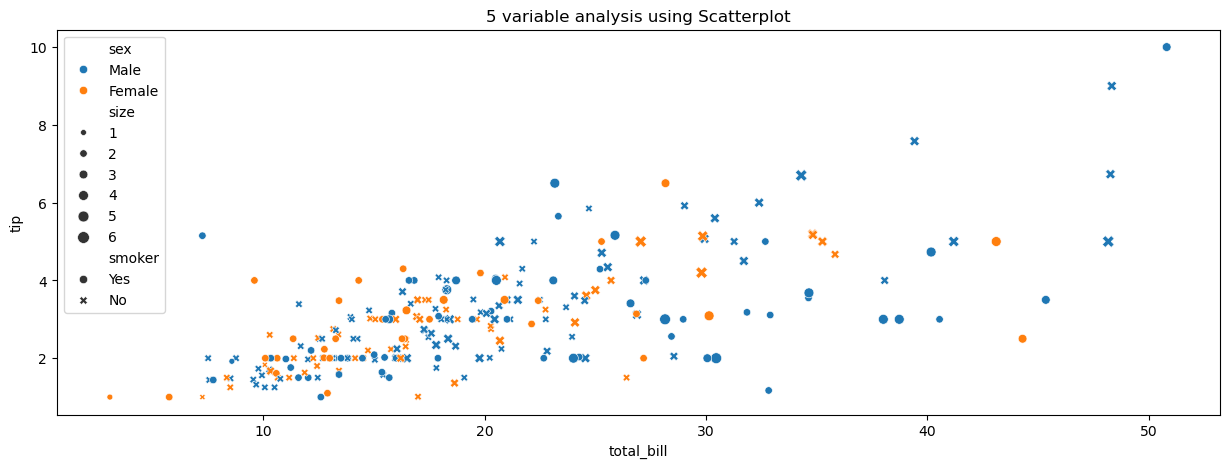

In [34]:
# sns.scatterplot(x=tips['total_bill'], y=tips['tip'])            # bivariate analysis

# multivariate analysis
# sns.scatterplot(x=tips['total_bill'], y=tips['tip'], hue=tips['sex'])            # analysing 3 variables 

pyplot.figure(figsize=(10,5))
sns.scatterplot(x=tips['total_bill'], y=tips['tip'], hue=tips['sex'], style=tips['smoker'])           # analysing 4 variables 
pyplot.title("4 variable analysis using Scatterplot")
pyplot.show()

# style parameter will distinguish the given column on the basis of different style of points shown in the scatterplot
# hue parameter will distinguish the given column on the basis of different hue/color of points shown in the scatterplot
# size parameter will distinguish the given column on the basis of their sizes of the points

pyplot.figure(figsize=(15,5))
sns.scatterplot(x=tips['total_bill'], y=tips['tip'], hue=tips['sex'], style=tips['smoker'], size=tips['size'])            # analysing 5 variables 
pyplot.title("5 variable analysis using Scatterplot")
pyplot.show()

<h1 style="color:blue">2).  PairPlot (Numerical-Numerical)</h1>

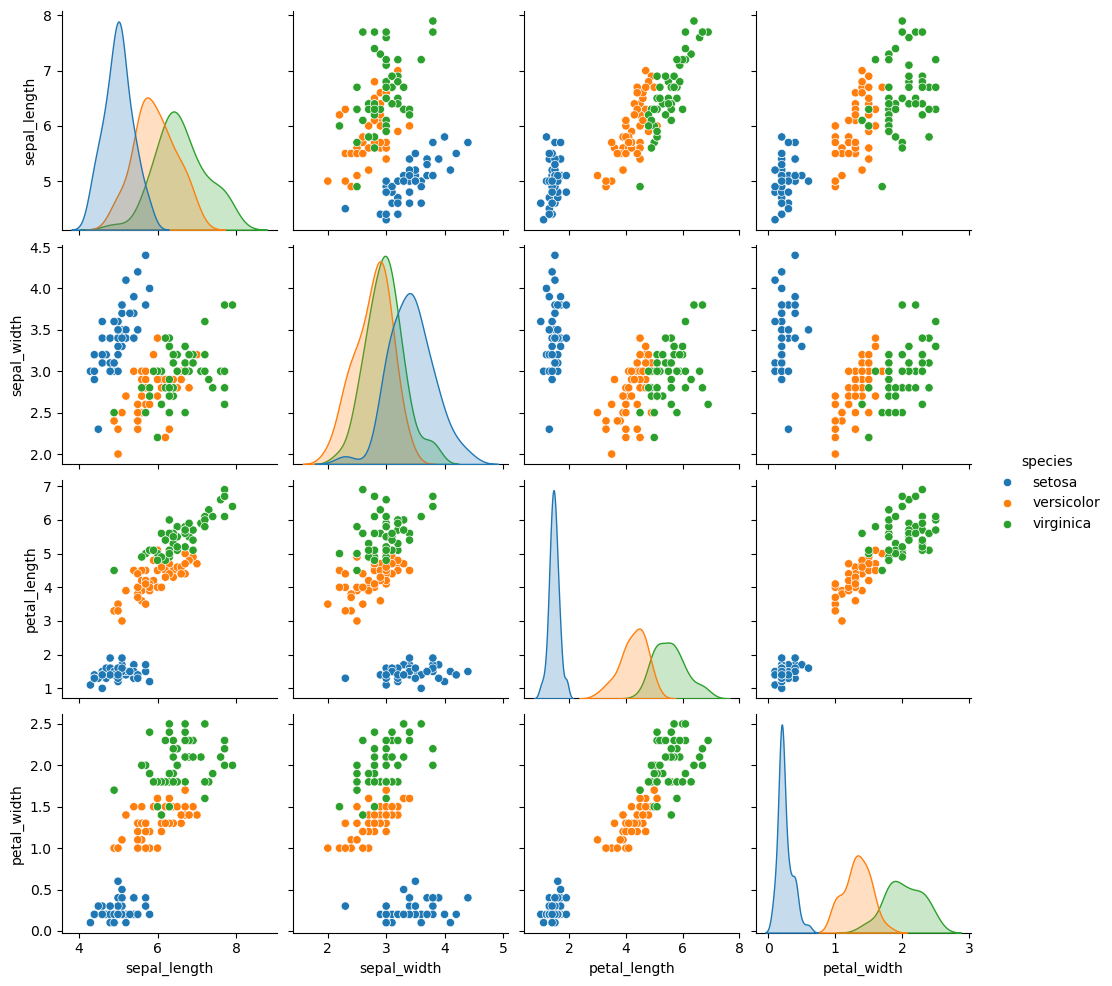

In [35]:
#  Colloection of all possible scatter plots, 
# it automatically detects all the possible numerical columns and give the scatterplot for every possible combination

sns.pairplot(iris, hue='species')

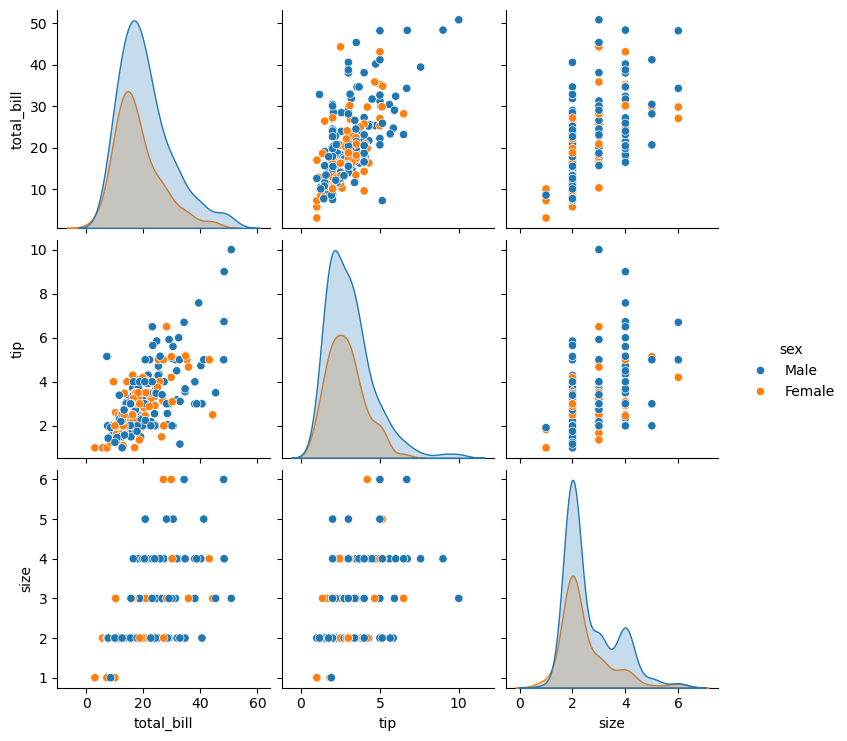

In [36]:
sns.pairplot(tips, hue='sex')

<h1 style="color:blue">3).  Bar-Plot (Numerical-Categorical)</h1>

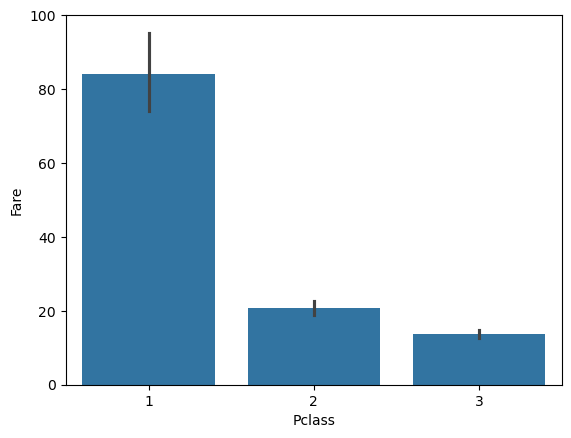

<Axes: xlabel='Pclass', ylabel='Fare'>

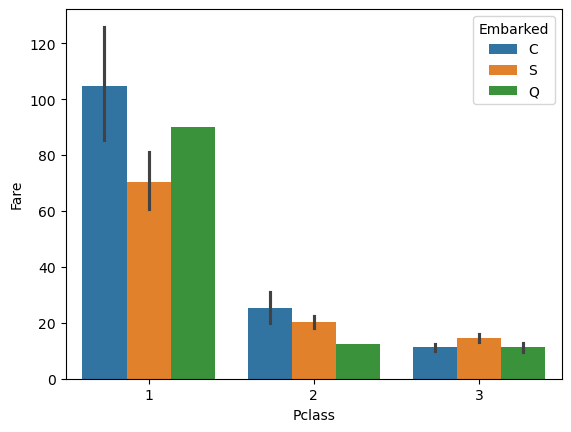

In [43]:
# In sns.barplot, the thin vertical line on top of each bar is an error bar, which by default represents:
#     95% Confidence Interval (CI) of the mean

sns.barplot(x=titanic['Pclass'], y=titanic['Fare']) 
pyplot.show()

# Multi-variate Analysis
# barplot according to the gender
sns.barplot(x=titanic['Pclass'], y=titanic['Fare'], hue=titanic['Embarked'])

In [46]:
# Missing error bars = insufficient or non-variable data, not a plotting error.
titanic.groupby(['Pclass', 'Embarked'])['Fare'].count()      # You’ll see very small counts for (1, Q) and (2, Q).

Pclass  Embarked
1       C            85
        Q             2
        S           127
2       C            17
        Q             3
        S           164
3       C            66
        Q            72
        S           353
Name: Fare, dtype: int64

<h1 style="color:blue">4).  Box-Plot (Numerical-Categorical)</h1>

<Axes: xlabel='Sex', ylabel='Age'>

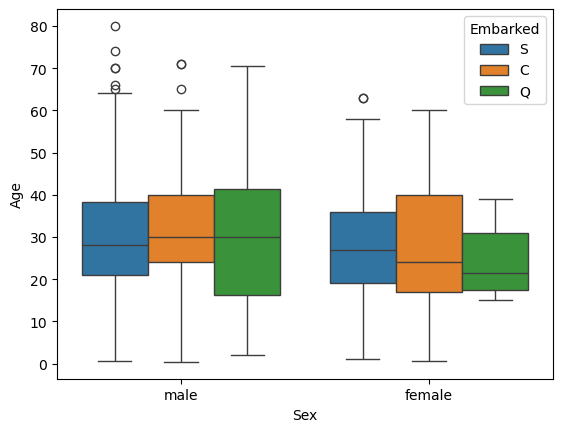

In [47]:
sns.boxplot(x=titanic['Sex'], y=titanic['Age'], hue=titanic['Embarked'])

<h1 style="color:blue">5).  DistPlot (Numerical-Categorical)</h1>

In [48]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)   
# as `distplot` is a deprecated function and will be removed in seaborn v0.14.0.
# to hide this warning we are using this

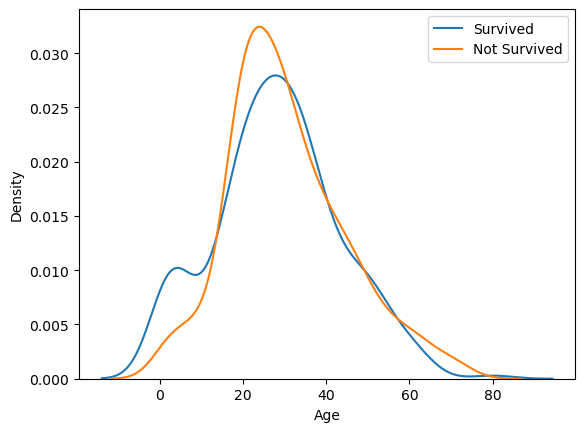

In [49]:
survived = titanic[titanic['Survived']==1]    # a new dataset in which only survived peoples dataset is there

sns.distplot(survived['Age'], hist=False,label='Survived')      #  or  sns.distplot(titanic[titanic['Survived']==0]['Age'], hist=False)  
# from the survived people's dataset, drawing a distplot with their Age ranges
sns.distplot(titanic[titanic['Survived']==0]['Age'], hist=False, label='Not Survived')  
pyplot.legend()     #  for multiple curves on the same axes. You must manually add labels and then call pyplot.legend().
pyplot.show()

<h1 style="color:blue">6).  Heatmap (Categorical-Categorical)</h1>

In [50]:
# A heatmap is a graphical representation of data where values are shown as colors.
# Color intensity shows magnitude (low → high)

pd.crosstab(titanic['Pclass'],titanic['Sex'])

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


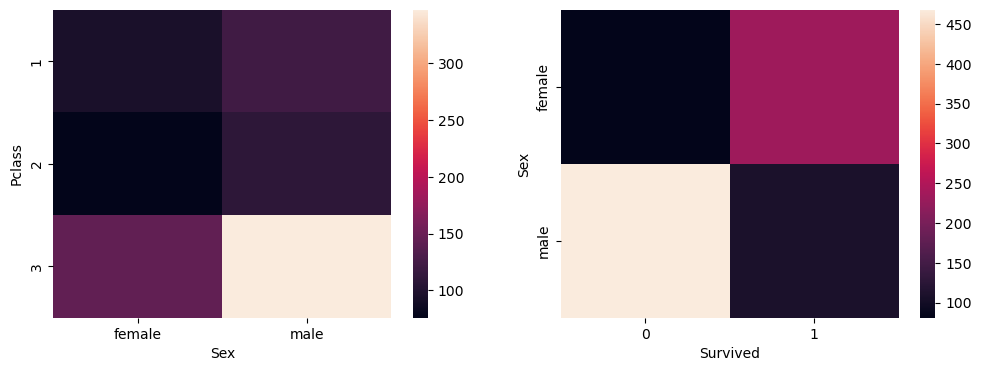

In [51]:
fig, axes = pyplot.subplots(1, 2, figsize=(12, 4))                    # 1 row, 2 columns
sns.heatmap(pd.crosstab(titanic['Pclass'], titanic['Sex']), ax=axes[0])

sns.heatmap(pd.crosstab(titanic['Sex'], titanic['Survived']), ax=axes[1])
pyplot.show()

<h3 style="color:brown">Analysing Barplot using groupby statements</h3>

<Axes: xlabel='Pclass'>

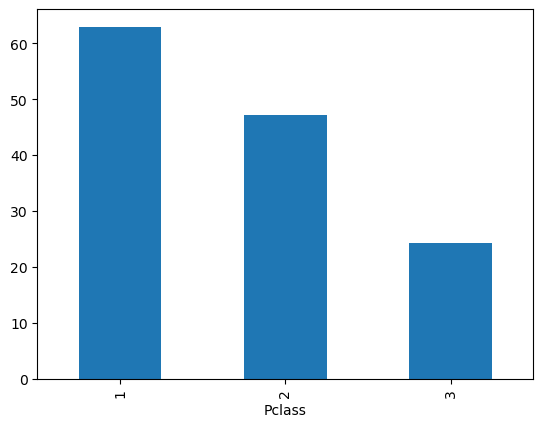

In [69]:
(titanic.groupby('Pclass')['Survived'].mean()*100).plot(kind='bar')

<h1 style="color:blue">7).  ClusterMap (Categorical-Categorical)</h1>

In [53]:
srs = pd.crosstab(tips['sex'], tips['day'])
srs

day,Thur,Fri,Sat,Sun
sex,,,,
Male,30,10,59,58
Female,32,9,28,18


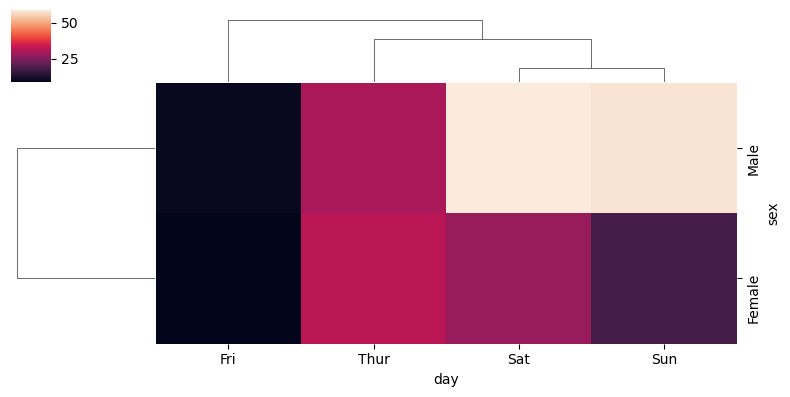

In [54]:
# A clustermap is an advanced heatmap that groups similar rows and columns using clustering.

sns.clustermap(srs, figsize=(8,4))

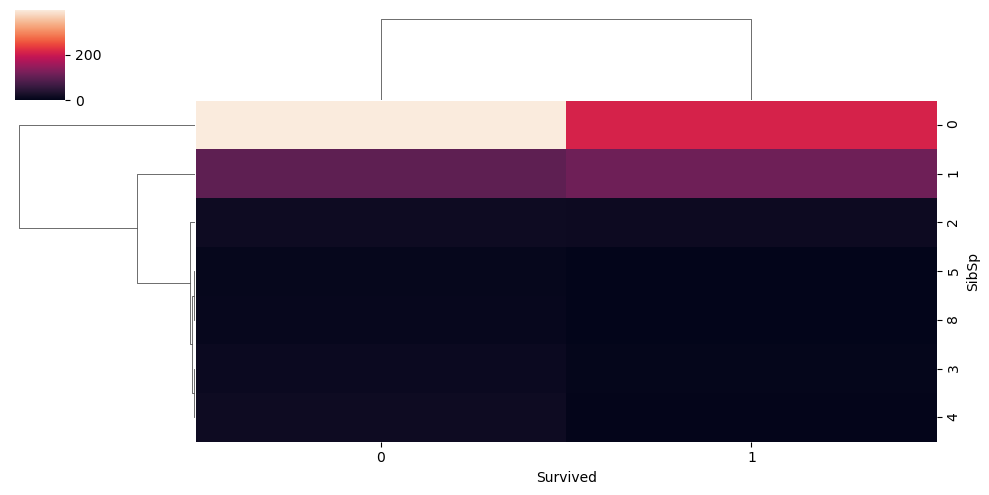

In [55]:
sns.clustermap(pd.crosstab(titanic['SibSp'], titanic['Survived']), figsize=(10,5))

<h1 style="color:blue">8).  Lineplot (Numerical-Numerical)</h1>

In [56]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [57]:
newDf = flights.groupby('year').sum(numeric_only=True).reset_index()
newDf.head()

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700


<Axes: xlabel='year', ylabel='passengers'>

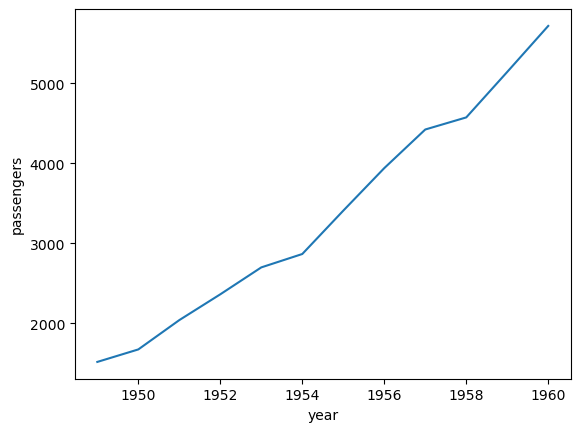

In [58]:
# lineplot is a special case of scatterplot
# lineplotis used when in x-axis you have a time based quantity(time, date, month, year)

sns.lineplot(x=newDf['year'], y=newDf['passengers'])

<h1> use of groupby, crosstab, pivot_table</h1>

In [59]:
# groupby → split → apply → combine

# crosstab → count relationships

# pivot_table → group + reshape + aggregate

In [60]:
# groupby()
# Groups data based on one or more columns and applies aggregation functions like sum, mean, count to each group.
iris.groupby('species').mean(numeric_only=True)

# groupby on the basis of multiple parameters
# df.groupby(['A', 'B', 'C']).sum()                                      # all parameters inside [] of groupby

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [61]:
# crosstab()
# Creates a frequency table showing how often combinations of two (or more) variables occur.
ct = pd.crosstab(titanic['Pclass'], titanic['Survived'])
display(ct)

pd.crosstab(index=[titanic['Pclass'],titanic['Sex']], columns=titanic['Survived'])                # for more than 2 variables

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Survived         0   1
Pclass Sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47

In [62]:
# pivot_table()
# Creates a spreadsheet-style summary table by grouping data and applying aggregations on values across rows and columns.

In [63]:
# to Keep all months (Jan–Dec always visible)	observed=False
data = flights.pivot_table(values='passengers', index='month', columns='year',observed=False)      # it has mainly 3 para: values, index and columns
display(data)

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


<Axes: xlabel='year', ylabel='month'>

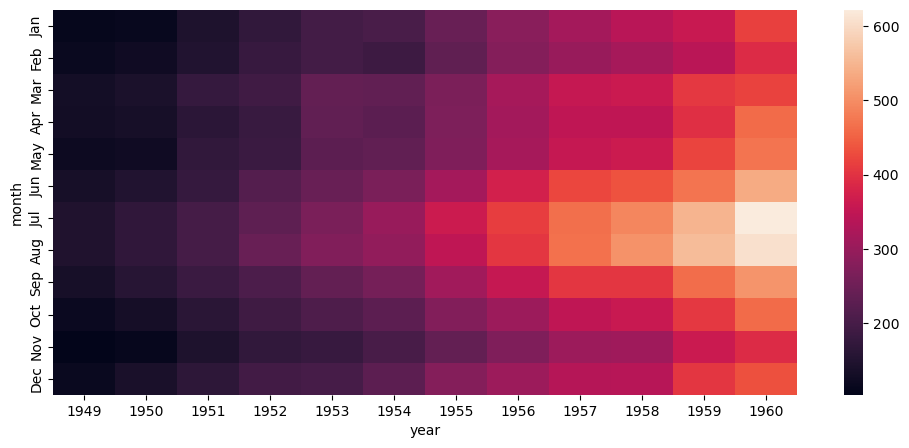

In [64]:
# to analyse a pivot table in more better way, we can use Heatmap or clustermap
pyplot.figure(figsize=(12,5))
sns.heatmap(data)

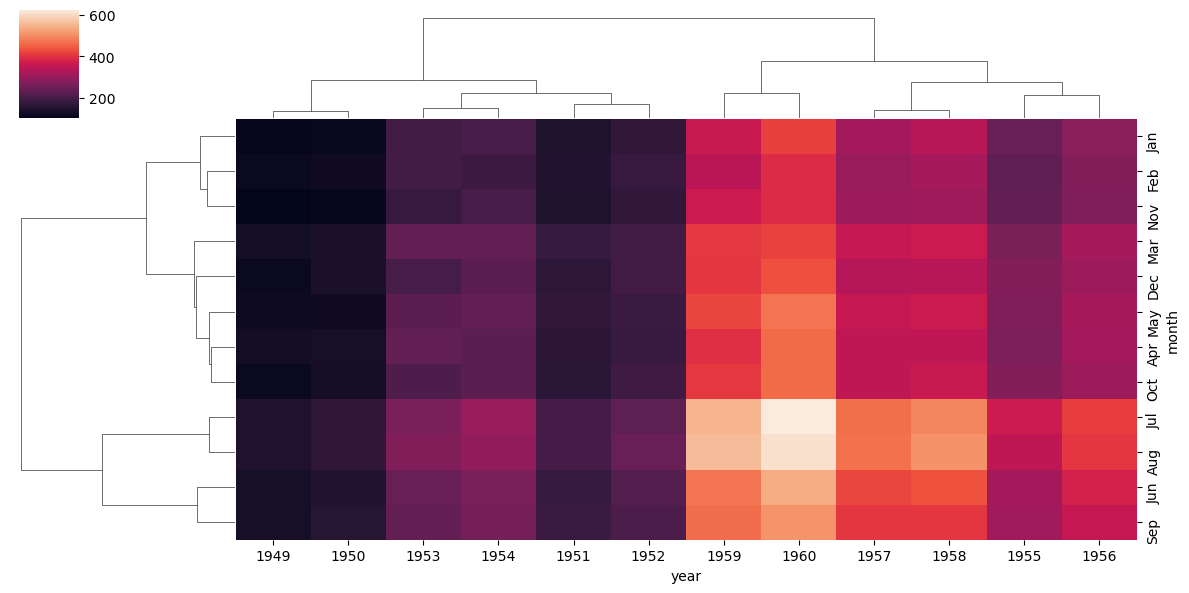

In [65]:
sns.clustermap(data, figsize=(12,6))     # keep those months nearby whose behaviour is similar, same with years